In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_pickle('./output/health_screenings_2020_1000ea.pkl')
df.head()

,gender,height,weight,waist,drinking,smoking
0,Male,165,60,72.1,Non-drinking,Non-smoking
1,Female,150,65,81.0,Non-drinking,Non-smoking
2,Female,155,55,70.0,Non-drinking,Non-smoking
3,Male,160,70,90.8,Non-drinking,Non-smoking
4,Female,155,50,75.2,Non-drinking,Non-smoking


In [4]:
# 01. 데이터 준비하기

In [9]:
# 음주 여부 및 흡연 상태 데이터 준비하기

# df에서 성별, 음주 여부의 그룹별 개수(인원)를 구하여 df_drinking에 저장
drinking = df.groupby(['gender', 'drinking'])['drinking'].count()
drinking

gender  drinking    
Female  Drinking        213
        Non-drinking    305
Male    Drinking        356
        Non-drinking    126
Name: drinking, dtype: int64

In [10]:
# df에서 성별, 흡연 상태의 그룹별 개수(인원)를 구하여 df_smoking에 저장
smoking = df.groupby(['gender', 'smoking'])['smoking'].count()
smoking

gender  smoking    
Female  Non-smoking    500
        Smoking         18
Male    Non-smoking    321
        Smoking        161
Name: smoking, dtype: int64

In [11]:
smoking.index

MultiIndex([('Female', 'Non-smoking'),
            ('Female',     'Smoking'),
            (  'Male', 'Non-smoking'),
            (  'Male',     'Smoking')],
           names=['gender', 'smoking'])

In [12]:
# 음주 여부와 흡연 상태에 대한 그룹별 개수의 시리즈를 데이터프레임으로 변경
df_drinking = drinking.to_frame(name='count')
df_drinking

count
gender drinking           
Female Drinking        213
       Non-drinking    305
Male   Drinking        356
       Non-drinking    126

In [13]:
df_smoking = smoking.to_frame(name='count')
df_smoking

count
gender smoking           
Female Non-smoking    500
       Smoking         18
Male   Non-smoking    321
       Smoking        161

In [14]:
# 데이터프레임의 인덱스를 초기화
df_drinking = df_drinking.reset_index()
df_smoking = df_smoking.reset_index()
df_drinking

,gender,drinking,count
0,Female,Drinking,213
1,Female,Non-drinking,305
2,Male,Drinking,356
3,Male,Non-drinking,126


In [15]:
# 2. 기본 막대 그래프 그리기
#
# matplotlib을 사용해서 기본 그래프 그리기
# add_subplot() 함수
# add_subplot() 함수의 인자를 통해 서브플롯 개수를 조정
# add_subplot(1, 2, 1)은 1 X 2 (행 X 열)의 서브플롯을 생성한다는 의미고,
# 세번째 인자 1인 생성된 두개의 서브플롯 중 첫번째 서브플롯을 의미
# 마찬가지로 (1, 2, 2)는 1 X 2 서브플롯에서 두번째 서브플롯을 의미

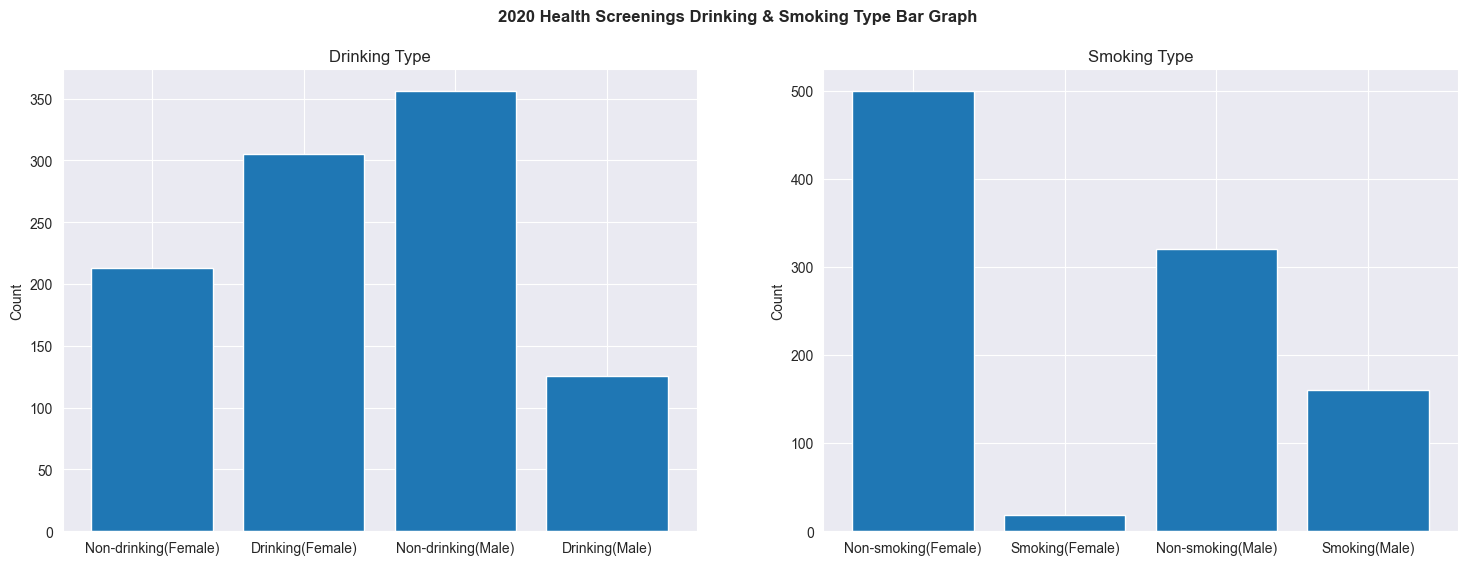

In [17]:
# 1) 전체 설정
fig = plt.figure(figsize=(18, 6))
fig.suptitle('2020 Health Screenings Drinking & Smoking Type Bar Graph', fontweight='bold')
index = np.arange(4) # x축 눈금 개수를 배열로 생성하고 index에 저장

# 2) 첫번째 서브플롯 설정
fig.add_subplot(1, 2, 1) # 1행 2열의 서브플롯 중 첫번째 서브플롯을 생성
# 첫번째 서브플롯에 그려질 음주 여부 데이터 개수 (인원)을 bar() 함수를 이용하여 지정
plt.bar(index, df_drinking['count'])
plt.title('Drinking Type')
plt.ylabel('Count')
# x축 눈금 이름을 지정
plt.xticks(index, ['Non-drinking(Female)', 'Drinking(Female)', 'Non-drinking(Male)', 'Drinking(Male)'])

# 3) 두번째 서브플롯 설정
fig.add_subplot(1, 2, 2) # 1행 2열의 서브 플롯 중 두번째 서브플롯을 생성
plt.bar(index, df_smoking['count'])
plt.title('Smoking Type')
plt.ylabel('Count')
# x축 눈금 이름을 지정
plt.xticks(index, ['Non-smoking(Female)', 'Smoking(Female)', 'Non-smoking(Male)', 'Smoking(Male)'])
plt.show()

In [18]:
# 3. 시본 막대 그래프 그리기

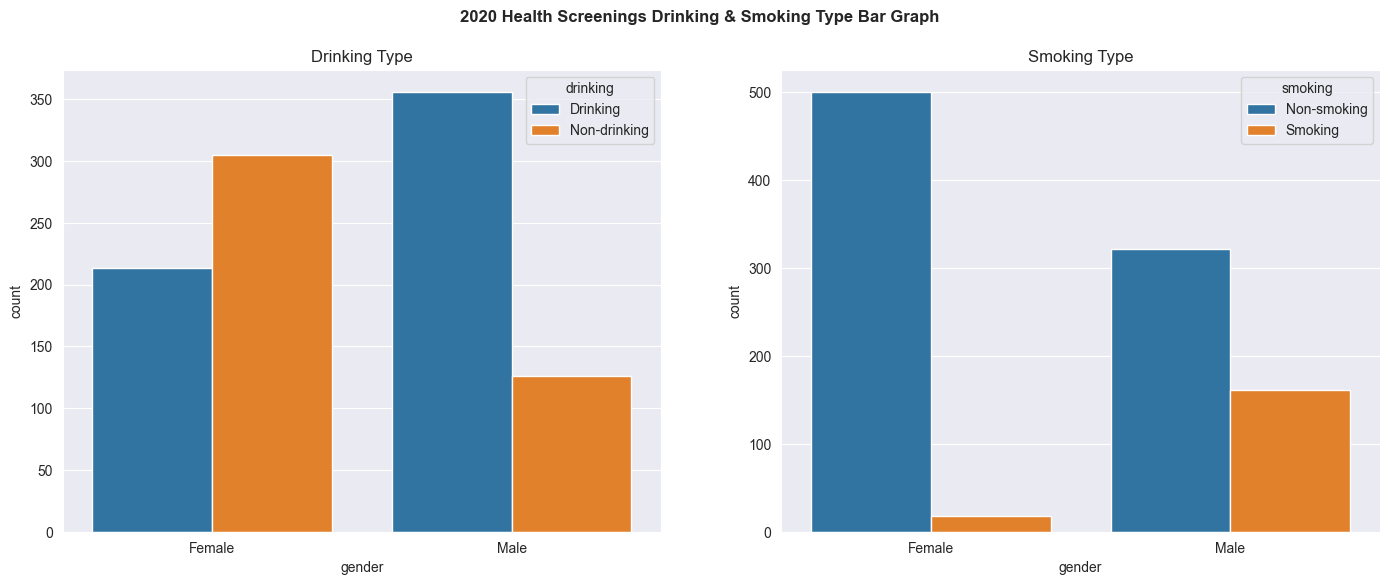

In [20]:
fig = plt.figure(figsize=(17, 6))

# 1행 2열의 서브플롯 생성
area1 = fig.add_subplot(1, 2, 1)
area2 = fig.add_subplot(1, 2, 2)

sns.barplot(data=df_drinking, x='gender', y='count', hue='drinking', ax=area1)
sns.barplot(data=df_smoking, x='gender', y='count', hue='smoking', ax=area2)
fig.suptitle('2020 Health Screenings Drinking & Smoking Type Bar Graph', fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')
plt.show()